# e3_64x64_8_layers_aug_SGD

This is the baseline experiment. It includes following components in the model:
* 64x64x3 input size
* Data Augmentations
* 8 Convolutional Layers
* Pooling Layer after skipping 1 convolutional Layer each
* SGD optimizer

### Importing required modules
Importing basic modules for training:
* torch
* datasets and transform
* dataloader

Importing Architecture:
* Architecture

Importing custom utils
* Trainer
* tester
* gen_line_charts

In [1]:
# torch and modules
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Main architecture
from Architecture import Architecture

# custom utils and modules
from modules.trainer import Trainer
from modules.tester import test
from modules.charts import gen_line_charts

## Load data
Use datasets, transforms and DataLoader to:
* LoadData
* Resize image to 64x64
* Randomly flip images horizontally
* Randomly rotate image by +-10 deg
* Add Color Jitters
* Randomly move the image
* transform to tensor
* Add a small Random Erasing between 2% to 10% erasing

For all three datasets: train, val and test

In [2]:
image_size = 64

aug_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.5
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.12, 0.12),
        scale=(0.8, 1.2)
    ),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.2,
        scale=(0.02, 0.10),
    )
])

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])


# make train sets
train_datasets = datasets.ImageFolder("./datasets/train", aug_transform)
train_loader = DataLoader(
    dataset=train_datasets, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    shuffle=True,
    persistent_workers=True
)

# make validation sets
val_datasets = datasets.ImageFolder("./datasets/val", transform)
val_loader = DataLoader(
    dataset=val_datasets, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# make test sets
test_datasets = datasets.ImageFolder("./datasets/test", transform)
test_loader = DataLoader(
    dataset=test_datasets, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

## Define and Use Architecture
define a model by calling Architecture class and add layers to it:
* 4 Convolutional Layer each followed with pooling layer
* 1 Flatten Layer followed with a 128 fully connected neural network
* 1 Linear layer to generate 3 class logits

In [3]:
model = Architecture()

Using function to loop adding 8 convolutional layers with a skip pooling layer 

In [4]:
def add_conv_layers(layers=1, skip_pool=0):
    # define in and out channels
    in_channels = 3
    out_channels = 8
    # size
    size = image_size
    # skip pool increase by one for calculation
    skip_pool = skip_pool+1
    # save a trainable parameters
    total_conv_params = 0
    # loop each layers to add on model
    for layer in range(layers):
        # Convolutional Layer
        model.add(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )
        # calculate trainable params
        total_conv_params += (((3*3*in_channels) + 1) * out_channels) + (2*out_channels)
        # Pooling Layer
        if  (layer + 1) % skip_pool:
            model.add(nn.MaxPool2d(2,2))
            size = size//2
        # update in and out channels
        if (layer<layers-1):
            in_channels = out_channels
            out_channels = out_channels*2
    # return total convolutional layer parameters
    return total_conv_params, out_channels, size

Call the `add_conv_layers()` and store parameters

In [5]:
conv_params, out_channels, size = add_conv_layers(8, 1)

# print conv params and out_channels
print(f"Total Trainable Parameters: {conv_params}")
print(f"Final Features: {out_channels}")
print(f"Final Feature size: {size}x{size}")

Total Trainable Parameters: 6297408
Final Features: 1024
Final Feature size: 4x4


use `model.add()` to add:
* Flatten Layer (64x4x4)
* Hidden Layer (64x4x4->128)
* Output Layer (128->3)

In [6]:
# calculate input
n_in = out_channels*size*size
print(f"Input vector size = {n_in}")

model.add(
    # Flatten
    nn.Flatten(),
    # Hidden Layer
    nn.Linear(n_in, 128),
    nn.ReLU(),
    # Output Layer
    nn.Linear(128, 3),
    nn.ReLU()
)

Input vector size = 16384


Calculating total parameters of the model

In [7]:
total_trainable_parameters = ((n_in*128)+128) + ((128*3)+3)
print(f"Total trainable parameters = {total_trainable_parameters}")

Total trainable parameters = 2097667


### Defining optimizer and Criterion
Optimizer:
* SGD
* learning rate = 2e-3
* no weight decay

Critetion:
* nn.CrossEntropy()

In [8]:
# optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=2e-3)
# criterion 
criterion = nn.CrossEntropyLoss()

## Train the model
Use Trainer Function to train the complete model for 100 epochs

In [9]:
trainer = Trainer(
    model,
    train_loader,
    val_loader,
    optimizer,
    "cuda",
    criterion
)

In [10]:
save_path = "./experiments/e3_64x64_8_layers_aug_SGD"

In [11]:
metrics = trainer.fit(100, save_path, 1)

EPOCH 5 completed | Training Loss = 0.9544044288236704 | Validation Loss = 0.9403222262859344
EPOCH 10 completed | Training Loss = 0.8955508861968766 | Validation Loss = 0.8943253616491954
EPOCH 15 completed | Training Loss = 0.8643210405734048 | Validation Loss = 0.8811586300532023
EPOCH 20 completed | Training Loss = 0.8411483257564146 | Validation Loss = 0.8658669302860896
EPOCH 25 completed | Training Loss = 0.806266669906787 | Validation Loss = 0.8862544159094493
EPOCH 30 completed | Training Loss = 0.8055076474574074 | Validation Loss = 1.3748455898215373
EPOCH 35 completed | Training Loss = 0.7945948163075234 | Validation Loss = 0.9253001858790716
EPOCH 40 completed | Training Loss = 0.7780769360599233 | Validation Loss = 0.8766963462034861
EPOCH 45 completed | Training Loss = 0.7440546417414252 | Validation Loss = 0.9918813635905583
EPOCH 50 completed | Training Loss = 0.7438630862022514 | Validation Loss = 0.9808849570651849
EPOCH 55 completed | Training Loss = 0.7395788271035

## Plot the training metrics
Plotting line chart of training metrics that shows curves of loss, accuracy, precision, recall and f1-score for training set and validation set. 

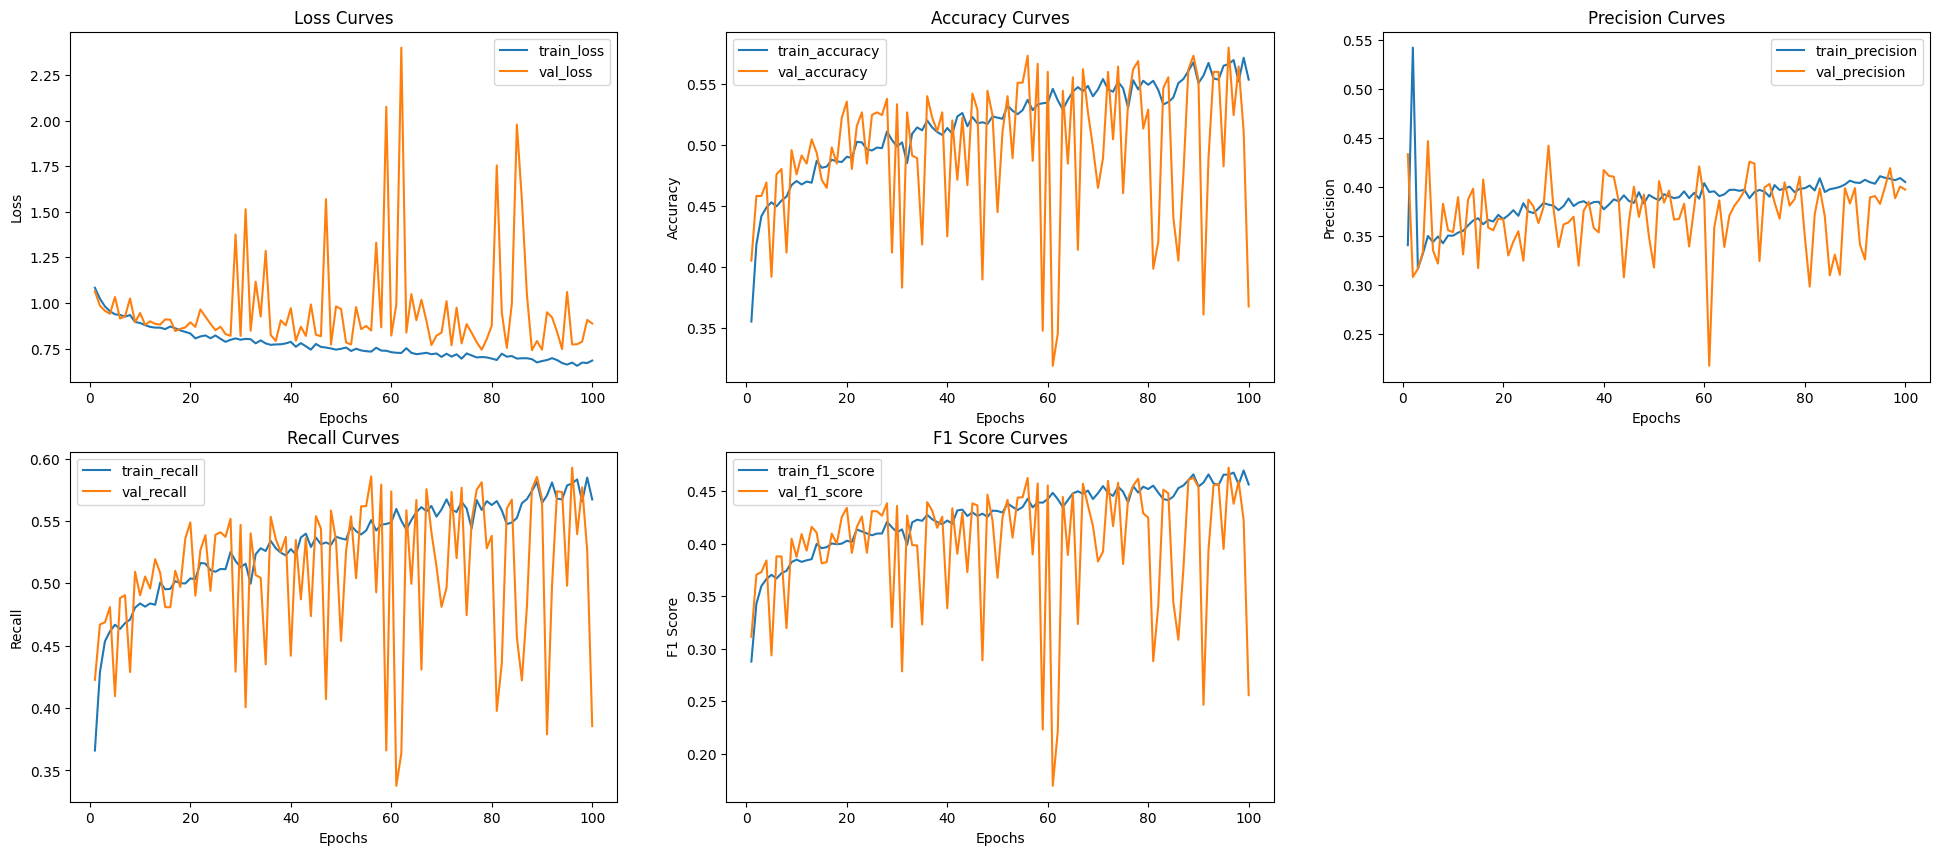

In [12]:
gen_line_charts(metrics, save_path, "training_metrics_graph.png", ["train_", "val_"])

### Model Evaluation
The loss curve on training set tends to decrease approaching 0.65. The training loss decreased till approximately 0.67. The model is converging very slowly. The validation set shows decrease in the loss approximately overlapping training loss curve till first 18 epoch. The validation loss curve starts showing extreme fluctuations from around epoch 30. The fluctuations are extreme where it reached above loss 2.25.

The accuracy, recall and F1-score curves shows similar growth having some overlap between training and validation set. The curves on training set shows very slow learning. The curves on validation set also tries to overlap but with extreme fluctuations creating deep valleys. The model shows very poor learning where every curve is below 0.6. Precision score shows even slower covergence. The precision on training set reaches 0.55 at epoch 2 which is the highest precision then drops to approximately 0.33 in third epoch. The training precision shows very little growth almost staying flat with minor fluctuations. By the 100th epoch precision curves on both training set and validation set barely makes growth upto 0.40. The F1-score looks similar to the Recall and Accuracy score showing similar behaviours but it reaches approximately to 0.45 byt the 100th epoch.

The model shows, it is having difficulties to understand patterns on training set. The generalization is still not good. From previous experiment we can notice model having a harder time to learn patterns where the augmentation was introduced. This experiment uses more convolutional layers, this may have hypothetically caused the gradient vanishing problem. The hypothesis should be tested one at a time to confirm the real culprit. The future experiment uses same architecture are this experiment without any augmentation. 